In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
pd.set_option('display.max_columns', 100)
sns.set_theme(style='ticks')


In [26]:
df = pd.read_csv('AB_NYC_2019.csv')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [27]:
# data cleaning
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [28]:
# last_review column should be in datetime format
df['last_review'] = pd.to_datetime(df['last_review'])

In [29]:
df.query('reviews_per_month.isnull()') # null values are due to 0 number of reviews, hence no reviews per month. replace  these NaN/NaT with 0 
df['last_review'] = df['last_review'].fillna(0)
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

In [30]:
#categorize to make the data more efficient in the long run.
df['neighbourhood_group'] = df['neighbourhood_group'].astype('category')
df['room_type'] = df['room_type'].astype('category')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype   
---  ------                          --------------  -----   
 0   id                              48895 non-null  int64   
 1   name                            48879 non-null  object  
 2   host_id                         48895 non-null  int64   
 3   host_name                       48874 non-null  object  
 4   neighbourhood_group             48895 non-null  category
 5   neighbourhood                   48895 non-null  object  
 6   latitude                        48895 non-null  float64 
 7   longitude                       48895 non-null  float64 
 8   room_type                       48895 non-null  category
 9   price                           48895 non-null  int64   
 10  minimum_nights                  48895 non-null  int64   
 11  number_of_reviews               48895 non-null  int64   
 12  last_review       

In [31]:
df.query('host_name.isna()').sort_values(by='host_id') # it semms like host_name has null due to low popularity (not so popular hosts)
df['host_name'] = df['host_name'].fillna('Unknown')
df['name'] = df['name'].fillna('Unknown')

In [32]:
df['host_name'].value_counts().head(10)

host_name
Michael         417
David           403
Sonder (NYC)    327
John            294
Alex            279
Blueground      232
Sarah           227
Daniel          226
Jessica         205
Maria           204
Name: count, dtype: int64

### Basic questions to explore:
- Which neighborhoods have the most listings?
- What’s the average price by borough (Manhattan, Brooklyn, Queens, etc.)?
- How do room types (Entire home, Private room, Shared room) affect price?
- What’s the distribution of minimum nights and availability?


In [33]:
# Which neighborhoods have the most listings?
neighbourhood_most_listings = (df.groupby('neighbourhood').agg(total_listing=('calculated_host_listings_count', 'sum'))\
                               .sort_values(by='total_listing', ascending=False))
neighbourhood_most_listings.head(10)

#Why Financial District has so many host listings, compared to the other???
# Try checking other factors such as room_type, price. Maybe price per room_type (check if the value of room_type is much affordable to the other neighbourhood)

,total_listing
neighbourhood,
Financial District,85454
Murray Hill,26125
Hell's Kitchen,25169
Midtown,25019
Theater District,18704
Chelsea,18098
Upper East Side,16282
Upper West Side,13360
Bedford-Stuyvesant,9688


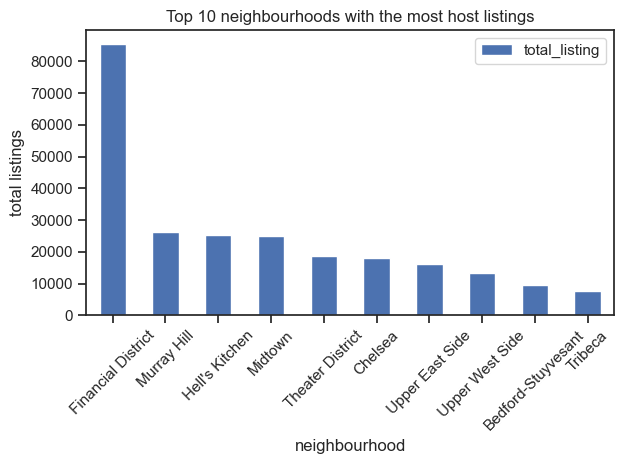

In [34]:
neighbourhood_most_listings.head(10).plot(kind='bar', rot=45)
plt.title('Top 10 neighbourhoods with the most host listings')
plt.ylabel('total listings')
plt.tight_layout()
plt.show()

In [35]:
top_10_neighbourhood = neighbourhood_most_listings.head(10).index
df_top_10_neighbourhood = df.query('neighbourhood.isin(@top_10_neighbourhood)').copy()

#average price per room type of every neighbourhood in top 10 host listings
avg_room_price = df_top_10_neighbourhood.groupby(['neighbourhood', 'room_type'])\
    .agg(avg_price=('price', 'mean'), total_count=('room_type','count'))\
    .sort_values(by='avg_price', ascending=False).sort_index()
avg_room_price

#maybe room type and avg price does not affect the number of host listings

C:\Users\user\AppData\Local\Temp\ipykernel_8280\3979102088.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_room_price = df_top_10_neighbourhood.groupby(['neighbourhood', 'room_type'])\


avg_price  total_count
neighbourhood      room_type                               
Bedford-Stuyvesant Entire home/apt  154.780641         1591
                   Private room      73.296860         2038
                   Shared room       50.376471           85
Chelsea            Entire home/apt  283.262195          820
                   Private room     156.741007          278
                   Shared room      140.666667           15
Financial District Entire home/apt  242.750000          572
                   Private room     165.623457          162
                   Shared room      208.100000           10
Hell's Kitchen     Entire home/apt  254.242628         1187
                   Private room     133.501488          672
                   Shared room       95.838384           99
Midtown            Entire home/apt  301.268182         1100
                   Private room     244.428910          422
                   Shared room       98.130435           23
Murray Hill        Entire home/apt  237.852130          399
                   Private room     137.802632           76
                   Shared room      178.900000           10
Theater District   Entire home/apt  318.182927          164
                   Private room     156.459016          122
                   Shared room       79.000000            2
Tribeca            Entire home/apt  561.818182          143
                   Private room     191.264706           34
                   Shared room             NaN            0
Upper East Side    Entire home/apt  216.908397         1310
                   Private room     117.097506          441
                   Shared room       83.808511           47
Upper West Side    Entire home/apt  262.045382         1256
                   Private room     122.640000          675
                   Shared room       95.225000           40

In [36]:
df_top_10_neighbourhood

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21 00:00:00,0.38,2,355
5,5099,Large Cozy 1 BR Apartment In Midtown East,7322,Chris,Manhattan,Murray Hill,40.74767,-73.97500,Entire home/apt,200,3,74,2019-06-22 00:00:00,0.59,1,129
6,5121,BlissArtsSpace!,7356,Garon,Brooklyn,Bedford-Stuyvesant,40.68688,-73.95596,Private room,60,45,49,2017-10-05 00:00:00,0.40,1,0
7,5178,Large Furnished Room Near B'way,8967,Shunichi,Manhattan,Hell's Kitchen,40.76489,-73.98493,Private room,79,2,430,2019-06-24 00:00:00,3.47,1,220
8,5203,Cozy Clean Guest Room - Family Apt,7490,MaryEllen,Manhattan,Upper West Side,40.80178,-73.96723,Private room,79,2,118,2017-07-21 00:00:00,0.99,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48886,36483010,Comfy 1 Bedroom in Midtown East,274311461,Scott,Manhattan,Midtown,40.75561,-73.96723,Entire home/apt,200,6,0,0,0.00,1,176
48888,36484087,"Spacious Room w/ Private Rooftop, Central loca...",274321313,Kat,Manhattan,Hell's Kitchen,40.76392,-73.99183,Private room,125,4,0,0,0.00,1,31
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0,0.00,2,9
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0,0.00,6,2


In [37]:
avg_room_price.head(10)

avg_price  total_count
neighbourhood      room_type                               
Bedford-Stuyvesant Entire home/apt  154.780641         1591
                   Private room      73.296860         2038
                   Shared room       50.376471           85
Chelsea            Entire home/apt  283.262195          820
                   Private room     156.741007          278
                   Shared room      140.666667           15
Financial District Entire home/apt  242.750000          572
                   Private room     165.623457          162
                   Shared room      208.100000           10
Hell's Kitchen     Entire home/apt  254.242628         1187

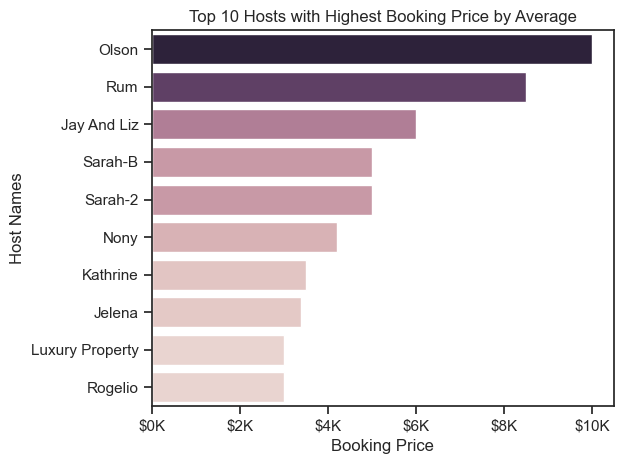

In [38]:
#data visualization of average booking price per host
host_mean_price = df.groupby('host_name')['price'].mean()\
    .reset_index().sort_values(by='price', ascending=False).head(10)
sns.barplot(data=host_mean_price, x='price', y='host_name', hue='price')
plt.title('Top 10 Hosts with Highest Booking Price by Average')
plt.xlabel('Booking Price')
plt.ylabel('Host Names')
plt.legend().remove()
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K'))
plt.tight_layout()